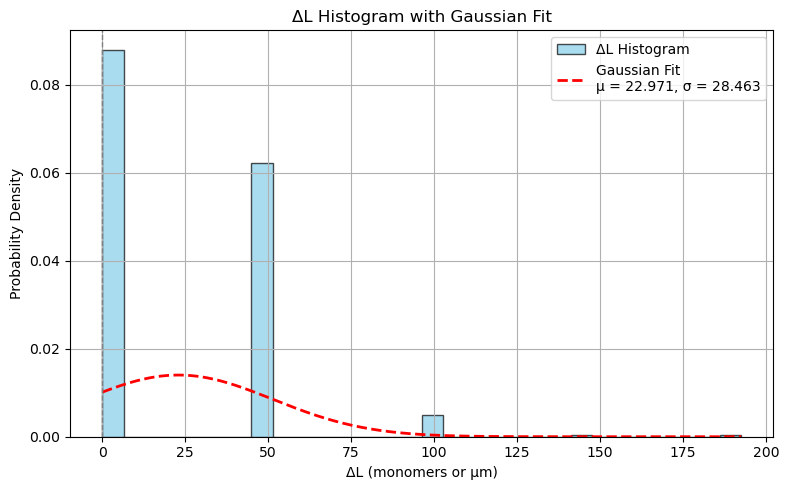

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Step 1: Load ΔL data from Excel using an absolute path ---
input_file = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\subunit_data_CD2AP_BE_AllStepSizes.xlsx'
column_name = "Delta_L"  # Replace with your actual column name

# Read the file
df = pd.read_excel(input_file)
delta_L = df[column_name].dropna()

# --- Step 2: Compute MSD ---
msd = np.mean(delta_L ** 2)

# --- Step 3: Fit a Gaussian (normal distribution) ---
mu, sigma = norm.fit(delta_L)

# --- Step 4: Plot histogram + Gaussian fit ---
plt.figure(figsize=(8, 5))

# Histogram
n, bins, patches = plt.hist(delta_L, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7, label="ΔL Histogram")

# Gaussian fit line
x = np.linspace(bins[0], bins[-1], 1000)
gaussian_pdf = norm.pdf(x, mu, sigma)
plt.plot(x, gaussian_pdf, 'r--', linewidth=2, label=f'Gaussian Fit\nμ = {mu:.3f}, σ = {sigma:.3f}')

# Formatting
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title("ΔL Histogram with Gaussian Fit")
plt.xlabel("ΔL (monomers or µm)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save plot to the same directory as input file
plot_path = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\CD2AP_BE_delta_L_histogram_with_fit.png'
plt.savefig(plot_path, dpi=300)
plt.show()

# --- Step 5: Save MSD, μ, and σ to Excel in the same directory ---
output_data = pd.DataFrame({
    "MSD": [msd],
    "Gaussian_Mean_μ": [mu],
    "Gaussian_StdDev_σ": [sigma]
})
output_path = r'C:\Users\madhu\OneDrive - University of Illinois - Urbana\Desktop\CD2AP_BE\CD2AP_BE_msd_and_fit_parameters.xlsx'
output_data.to_excel(output_path, index=False)
